In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
#from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline

In [95]:
df = pd.read_csv(r"C:\Users\de\Downloads\ipl_data.csv")

    




In [96]:
df

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [97]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


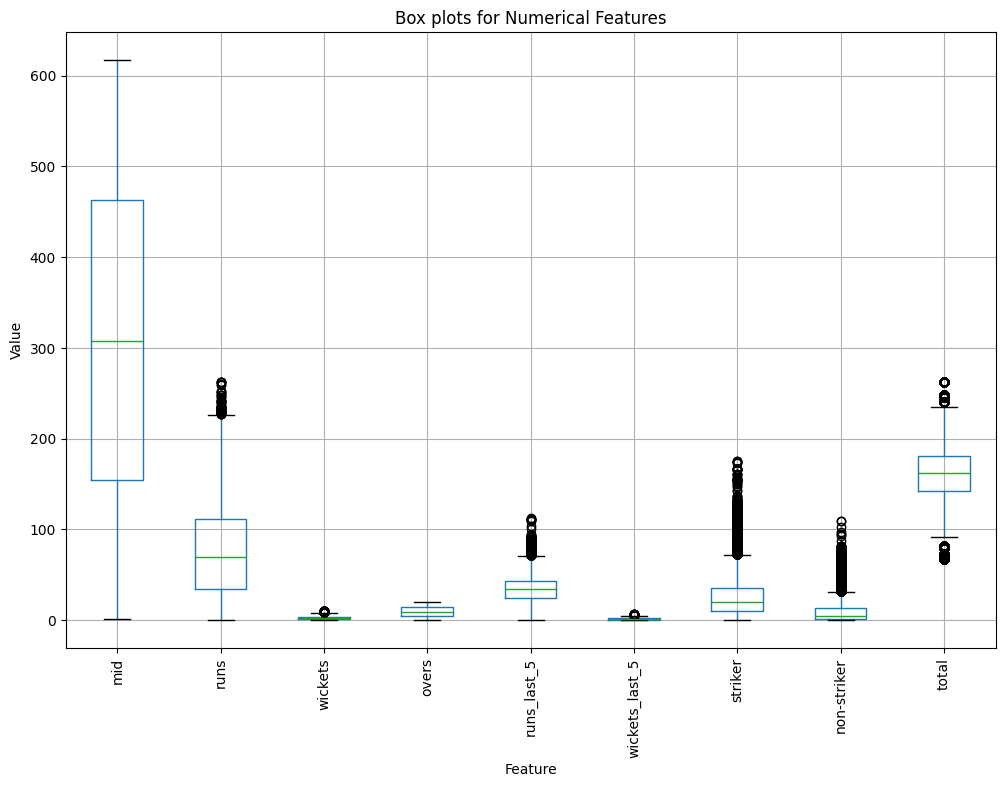

In [98]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
plt.figure(figsize=(12, 8))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [100]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [101]:
df.describe(include = "O")

,date,venue,bat_team,bowl_team,batsman,bowler
count,76014,76014,76014,76014,76014,76014
unique,442,35,14,14,411,329
top,2010-03-25,M Chinnaswamy Stadium,Mumbai Indians,Delhi Daredevils,SK Raina,Harbhajan Singh
freq,257,7443,10213,10245,1921,1404


<Axes: >

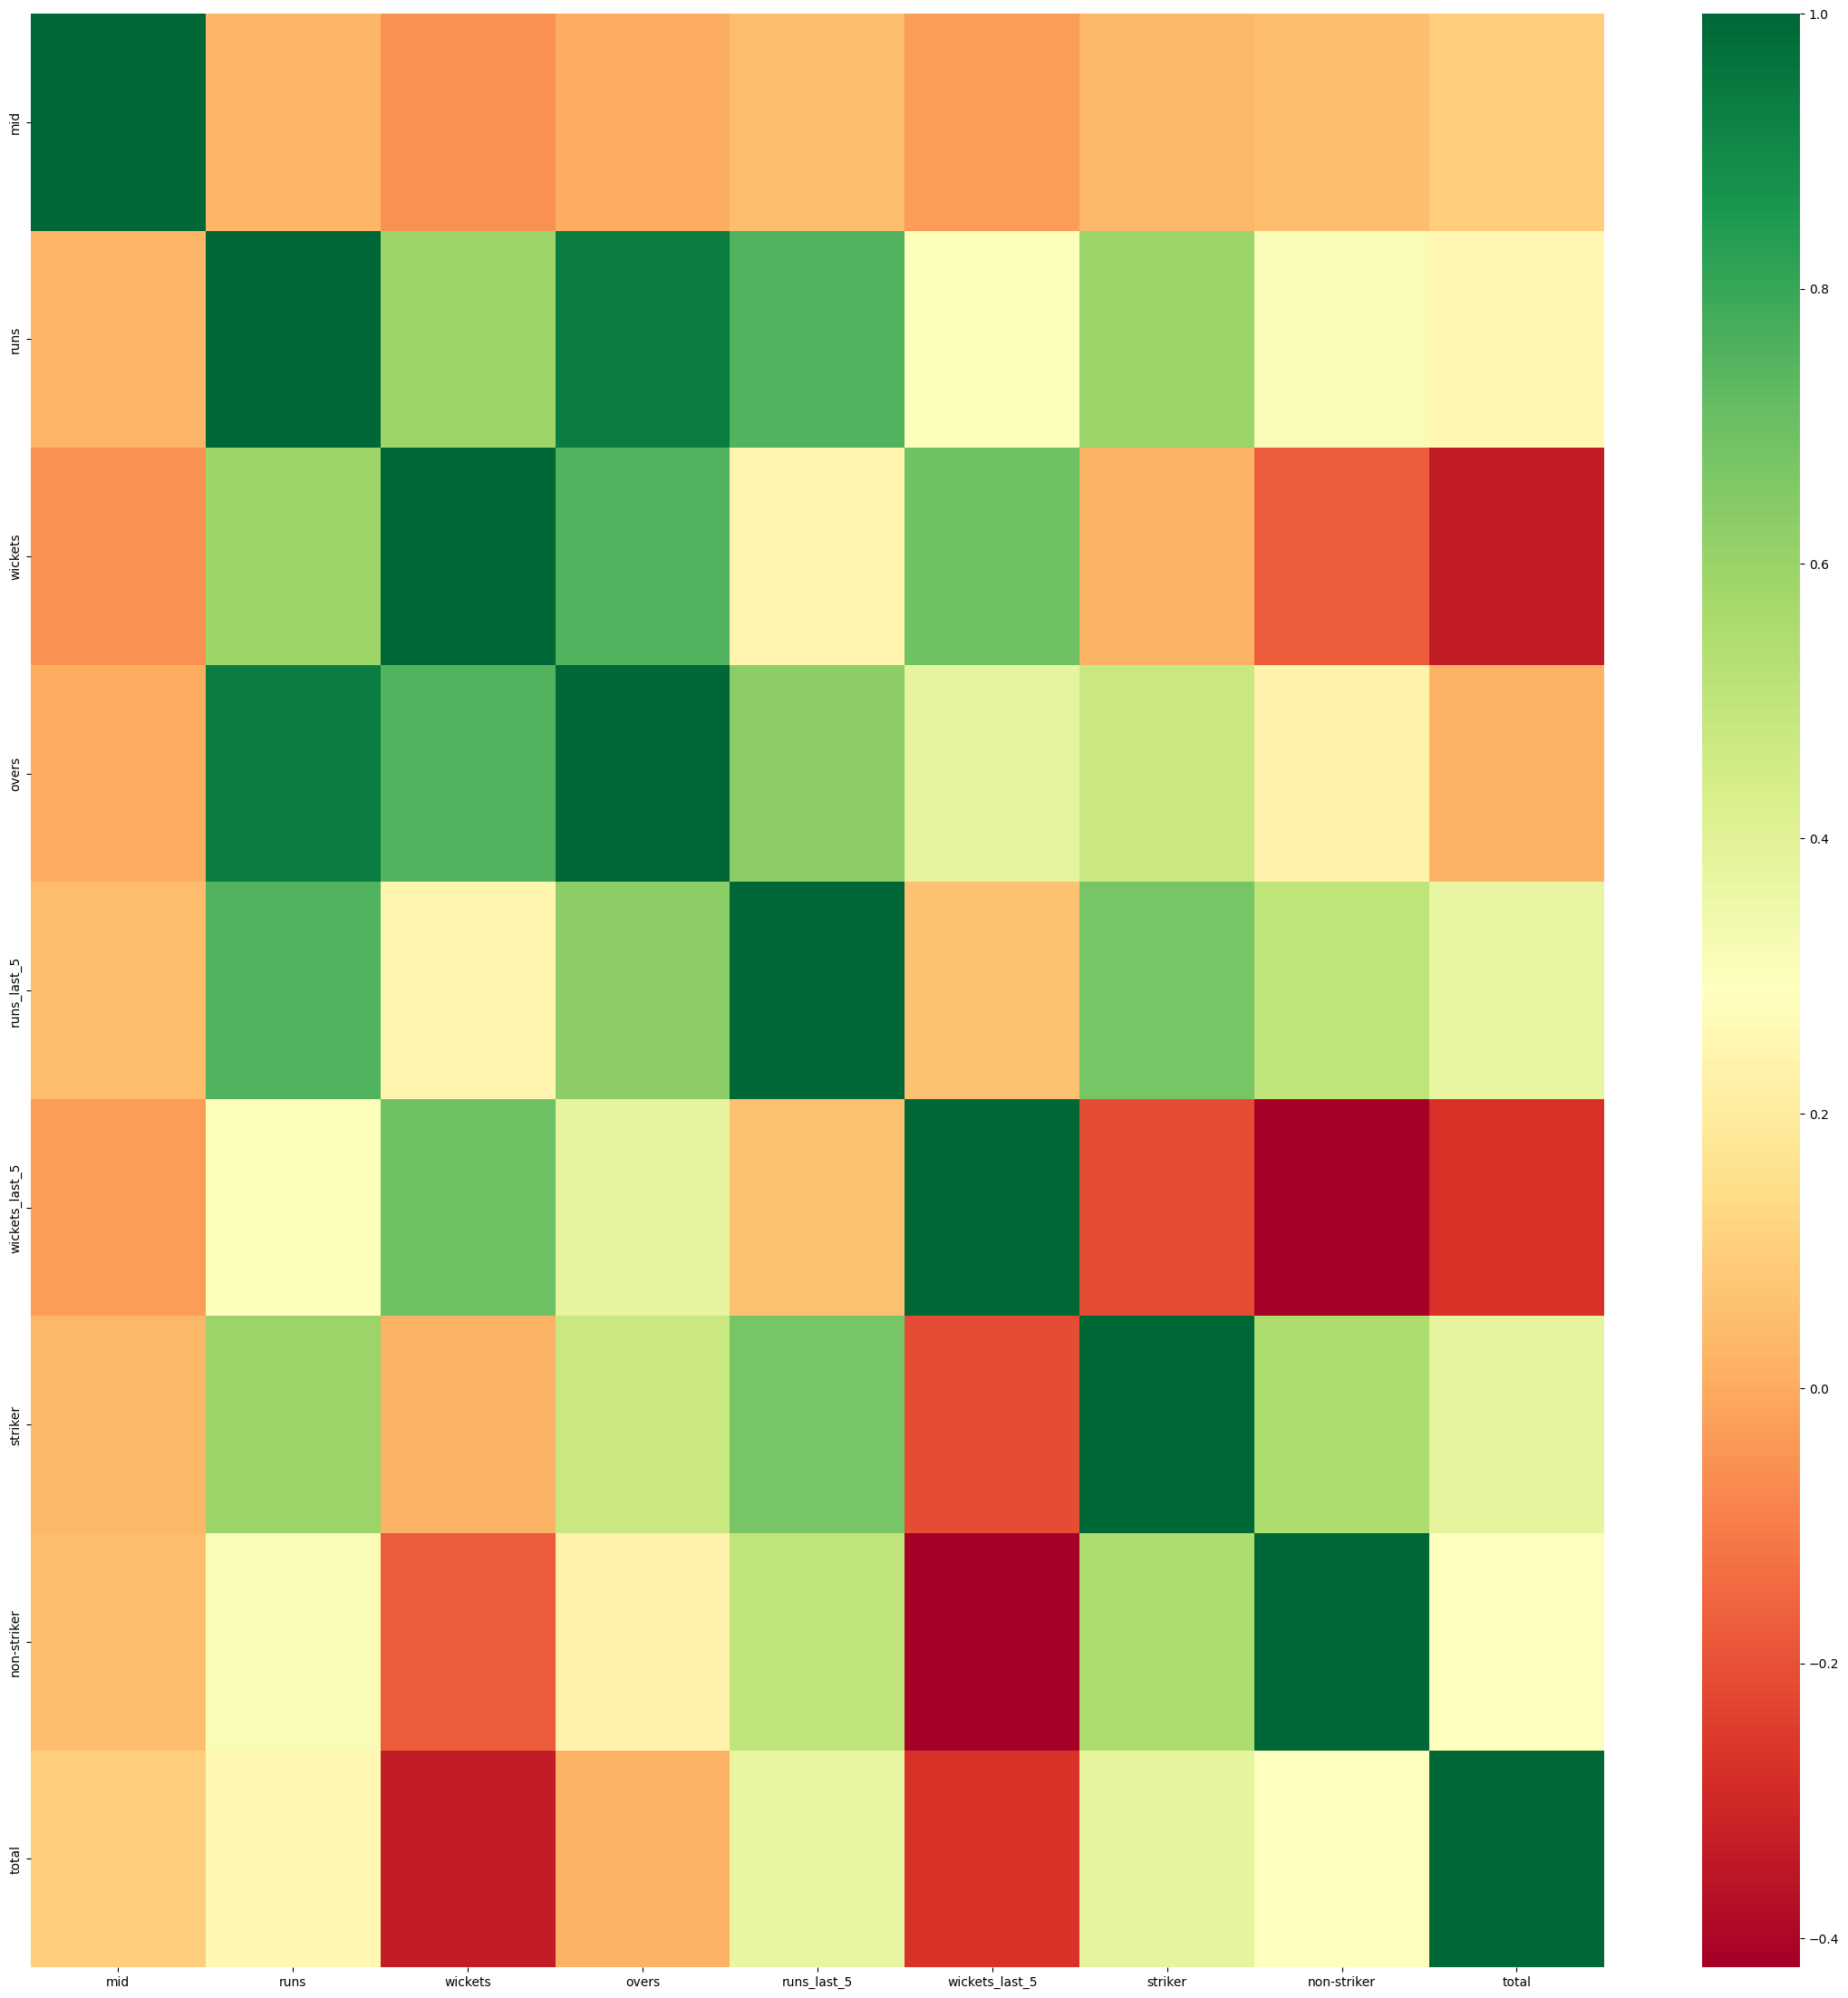

In [102]:
plt.figure(figsize=(28,28))#increase plot size
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(),cmap="RdYlGn")

In [103]:
np.where(df.select_dtypes(include=['int', 'float']).corr()>0.9)

(array([0, 1, 1, 2, 3, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 3, 2, 1, 3, 4, 5, 6, 7, 8]))

In [104]:
df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [105]:
df[['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total']]
      

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [106]:
df['venue'].value_counts()

venue
M Chinnaswamy Stadium                                   7443
Feroz Shah Kotla                                        7068
Eden Gardens                                            7049
Wankhede Stadium                                        7048
MA Chidambaram Stadium, Chepauk                         5972
Rajiv Gandhi International Stadium, Uppal               5827
Punjab Cricket Association Stadium, Mohali              4247
Sawai Mansingh Stadium                                  4110
Dr DY Patil Sports Academy                              2088
Subrata Roy Sahara Stadium                              2086
Maharashtra Cricket Association Stadium                 1843
Kingsmead                                               1731
Sardar Patel Stadium, Motera                            1484
Brabourne Stadium                                       1380
SuperSport Park                                         1377
Punjab Cricket Association IS Bindra Stadium, Mohali    1342
Saurashtra Cricket

In [107]:
df['bat_team'].value_counts()

bat_team
Mumbai Indians                 10213
Kings XI Punjab                 9219
Chennai Super Kings             9142
Royal Challengers Bangalore     8331
Kolkata Knight Riders           8033
Delhi Daredevils                7152
Rajasthan Royals                6643
Deccan Chargers                 5280
Sunrisers Hyderabad             5216
Pune Warriors                   2448
Gujarat Lions                   1726
Rising Pune Supergiant           994
Kochi Tuskers Kerala             876
Rising Pune Supergiants          741
Name: count, dtype: int64

In [108]:
df['bowl_team'].value_counts()

bowl_team
Delhi Daredevils               10245
Royal Challengers Bangalore     9661
Mumbai Indians                  9271
Kolkata Knight Riders           9211
Kings XI Punjab                 8405
Rajasthan Royals                7773
Chennai Super Kings             6497
Deccan Chargers                 3984
Sunrisers Hyderabad             3589
Pune Warriors                   3083
Gujarat Lions                   1970
Rising Pune Supergiant           962
Kochi Tuskers Kerala             736
Rising Pune Supergiants          627
Name: count, dtype: int64

In [109]:
df['batsman'].value_counts()

batsman
SK Raina          1921
V Kohli           1825
S Dhawan          1730
RG Sharma         1726
MS Dhoni          1584
                  ... 
T Henderson          1
NJ Rimmington        1
LH Ferguson          1
P Parameswaran       1
V Pratap Singh       1
Name: count, Length: 411, dtype: int64

In [110]:
df['bowler'].value_counts()

bowler
Harbhajan Singh    1404
PP Chawla          1399
P Kumar            1386
SL Malinga         1333
UT Yadav           1304
                   ... 
DB Ravi Teja          6
KS Williamson         6
CK Kapugedera         6
P Prasanth            6
SA Yadav              6
Name: count, Length: 329, dtype: int64

In [111]:
df['runs'].value_counts()

runs
1      895
0      808
5      697
2      649
4      643
      ... 
259      1
253      1
245      1
239      1
240      1
Name: count, Length: 252, dtype: int64

In [112]:
df['wickets'].value_counts()

wickets
1     14900
0     14840
2     13927
3     11568
4      9124
5      5208
6      3334
7      1784
8       856
9       426
10       47
Name: count, dtype: int64

In [113]:
df['overs'].value_counts()

overs
0.1     655
0.4     652
1.1     650
3.5     649
2.3     649
       ... 
8.0      17
13.0     15
12.0     14
11.0     14
10.0     11
Name: count, Length: 140, dtype: int64

In [114]:
df['runs_last_5'].value_counts()

runs_last_5
34     2408
33     2328
35     2317
36     2289
32     2281
       ... 
95        1
100       1
104       1
109       1
113       1
Name: count, Length: 102, dtype: int64

In [115]:
df['wickets_last_5'].value_counts()

wickets_last_5
1    27238
0    24918
2    16102
3     5802
4     1534
5      350
6       65
7        5
Name: count, dtype: int64

In [116]:
df['striker'].value_counts()

striker
4      2266
1      2188
5      2087
6      1993
10     1981
       ... 
173       1
148       1
132       1
152       1
158       1
Name: count, Length: 155, dtype: int64

In [117]:
df['non-striker'].value_counts()

non-striker
0      12246
1       9642
2       6210
3       4174
4       3994
       ...  
78         1
87         1
93         1
97         1
103        1
Name: count, Length: 88, dtype: int64

In [118]:
df['total'].value_counts()

total
165    1746
178    1505
183    1495
163    1485
168    1485
       ... 
98      110
103     103
73       98
81       96
70       91
Name: count, Length: 138, dtype: int64

In [119]:
df['mid'].value_counts()

mid
309    132
32     131
115    131
106    131
299    131
      ... 
403     91
241     74
479     65
495     63
384     50
Name: count, Length: 617, dtype: int64

In [120]:
df['date'].value_counts()

date
2010-03-25    257
2011-04-22    257
2012-05-20    256
2015-04-25    255
2014-05-14    254
             ... 
2014-05-02    103
2008-05-07    103
2008-05-16     98
2012-04-05     74
2015-05-13     63
Name: count, Length: 442, dtype: int64

In [121]:
len(df.columns)

15

In [122]:
OHE_columns=['venue']
standard_scaler=['runs','overs']
label_encoder=['venue']
pass_through=['non-striker']


In [123]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [124]:
def same(x):
    return x

In [125]:
no_trans=FunctionTransformer(same)

In [126]:
preprocessor = ColumnTransformer([
    ("OHE_columns", OneHotEncoder(), OHE_columns),
    ("Label_encoder", ModifiedLabelEncoder(), label_encoder),
    ("Standard_scaler", StandardScaler(), standard_scaler),
    ('Pass_through',no_trans,pass_through)])

In [127]:
preprocessor

,transformers,"[('OHE_columns', ...), ('Label_encoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [128]:
import pickle

with open("dtrfpreprocesspickle.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

In [129]:
df.isnull().sum() 

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [130]:
X = df.drop("total",axis=1) 
y = df["total"]

In [131]:
# Spliting the data into train and test
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=33)

In [132]:
import pickle   # importing pickle for saving and loading machine learning models
import pandas as pd  # importing pandas for analyzing, cleaning, exploring, and manipulating data
from sklearn.model_selection import train_test_split  # importing train_test_split for spliting the data into training and testing
#from preprocessor import *  # importing * for import all functions at once
from imblearn.over_sampling import SMOTE  # importing SMOTE for Balancing the Data

In [133]:
# Spliting the data into train and test
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=33)

In [134]:
from sklearn.preprocessing import LabelEncoder

class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)


In [135]:
def same(x):
    return x

In [136]:
# Load a preprocessor object from a pickled file
with open(r"C:\Users\de\dtrfpreprocesspickle.pkl","rb")as f:
    preprocessor=pickle.load(f)

In [137]:
preprocessor

,transformers,"[('OHE_columns', ...), ('Label_encoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [138]:
# Transform the training data using the preprocessor object or PipeLine
processed_x_train = preprocessor.fit_transform(x_train)
processed_x_test = preprocessor.transform(x_test)

C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [139]:
processed_x_train[0]  # Checking first rows of processed_x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 39)>

In [140]:
#from sklearn.utils.class_weight import compute_sample_weight
#sample_weights = compute_sample_weight(class_weight={1:3},y=y_train)  # You need to define this function

In [141]:
import numpy as np

print(np.unique(y_train))
print(len(np.unique(y_train)))


[ 67  70  73  80  81  82  92  94  95  97  98  99 100 101 103 105 106 107
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 211 212 213 214 215 218 221
 222 223 226 227 230 231 232 235 240 246 248 263]
138


In [142]:
# Initialize the SMOTE (Synthetic Minority Over-sampling Technique) object into variable
from imblearn.over_sampling import SMOTE
smote=SMOTE()

In [143]:
# Apply SMOTE to the training data to balance the class distribution
x_train_smote,y_train_smote=smote.fit_resample(processed_x_train,y_train)

In [144]:
import pandas as pd

# Check categorical columns
cat_cols = x_train.select_dtypes(include=['object']).columns
print(cat_cols)

# One-hot encoding
x_train_encoded = pd.get_dummies(x_train, columns=cat_cols)
x_test_encoded = pd.get_dummies(x_test, columns=cat_cols)

# Make both datasets have same columns
x_train_encoded, x_test_encoded = x_train_encoded.align(
    x_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)


Index(['date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler'], dtype='object')


In [145]:
x_train = x_train.drop(columns=['date'])
x_test = x_test.drop(columns=['date'])


In [146]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

model.fit(x_train_encoded, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [147]:
from sklearn.tree import DecisionTreeClassifier        #importing decision tree from sklearn.tree
dt=DecisionTreeClassifier()             #object creation for decision tree
dt.fit(x_train_smote,y_train_smote)    # sample_weight=sample_weights    #train the model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [148]:
from sklearn.metrics import accuracy_score,f1_score,classification_report
y_predict=dt.predict(processed_x_test)    # predicting the model
acc=accuracy_score(y_test,y_predict)
acc

0.6070300989265418

In [149]:
#f1_score(y_test,y_predict)    # Checking F1_Score

In [150]:
# Train
model.fit(processed_x_train, y_train)

# Predict
y_pred = model.predict(processed_x_test)


In [151]:
y_pred = model.predict(processed_x_test)


In [152]:
# Train
model.fit(processed_x_train, y_train)

# Predict
y_pred = model.predict(processed_x_test)


In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)

x_test_processed = preprocessor.transform(x_test)

model.fit(x_train_processed,y_train)

y_pred = model.predict(x_test_processed)


In [ ]:
# fit encoder
x_train_processed = preprocessor.fit_transform(x_train)

# transform test using same encoder
x_test_processed = preprocessor.transform(x_test)

# train model
model.fit(x_train_processed, y_train)

# predict
y_pred = model.predict(x_test_processed)


In [ ]:
print(x_train.shape)
print(x_test.shape)

print(x_train.columns)
print(x_test.columns)


In [ ]:
print(x_train_processed.shape)
print(x_test_processed.shape)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)

x_test_processed = preprocessor.transform(x_test)


In [ ]:
print(x_train_processed.shape)
print(x_test_processed.shape)


In [ ]:
params = {
    "criterion": ["squared_error"],
    "splitter": ["best"],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [ ]:
tree_cv = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

tree_cv.fit(processed_x_train, y_train)


best_params = tree_cv.best_params_

print("Best Parameters:")
print(best_params)


In [ ]:
best_tree = tree_cv.best_estimator_

y_pred = best_tree.predict(processed_x_test)


In [154]:
y_pred

array([141., 136., 161., ..., 171., 145., 151.], shape=(19004,))

In [155]:
from sklearn.tree import DecisionTreeRegressor
import time

start = time.time()

tree = DecisionTreeRegressor(random_state=42)
tree.fit(processed_x_train, y_train)

print("Time:", time.time() - start)


Time: 6.704948425292969


In [156]:
print(processed_x_train.shape)
print(type(processed_x_train))


(57010, 39)
<class 'scipy.sparse._csr.csr_matrix'>


In [157]:
from sklearn.tree import DecisionTreeRegressor
import time

start = time.time()

tree = DecisionTreeRegressor(random_state=42)
tree.fit(processed_x_train, y_train)

print("Time for one tree:", time.time() - start)


Time for one tree: 5.2442169189453125


In [158]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(processed_x_train, y_train)

y_pred_dt = dt.predict(processed_x_test)

print("R2:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))


R2: 0.44946515912713614
MAE: 15.655498532445664
RMSE: 21.739211662419855


In [159]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

dt = DecisionTreeRegressor(random_state=42)

search = RandomizedSearchCV(
    dt,
    param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(processed_x_train, y_train)


Fitting 3 folds for each of 5 candidates, totalling 15 fits


,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5]}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [160]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

dt_r2 = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree")
print("R2:", dt_r2)
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)


Decision Tree
R2: 0.44946515912713614
MAE: 15.655498532445664
RMSE: 21.739211662419855


In [161]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=2,
    criterion='squared_error',
    random_state=42
)

dt.fit(processed_x_train, y_train)

y_pred_dt = dt.predict(processed_x_test)


In [162]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))


R2 Score: 0.524244475242876
MAE: 13.968065587154683
RMSE: 20.208929406220328


In [163]:
best_params = tree_cv.best_params_

dt = DecisionTreeRegressor(
    **best_params,
    random_state=42
)

dt.fit(processed_x_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [164]:
tree_cv.fit(processed_x_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'criterion': ['squared_error'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [165]:
processed_x_train = preprocessor.fit_transform(x_train)
processed_x_test = preprocessor.transform(x_test)


C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
